This notebook is a tutorial for using ReX to explain the classification of spectra. I'll be using Raman spectra for this demonstration. I'll be using google colab, but with minor adjustments should be fine for any notebook.

First we need to install ReX. In google colab this may require you to restart the notebook

In [1]:
pip install rex_xai

On google colab You'll need to mount your drive to get access to the data/model

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Define the path to the data/model. Change as needed.

In [3]:
model_path = "/content/drive/My Drive/XAI/Raman XAI/ReX Demo/simple_steel_DNA_model.pt"

Define your model and load in the weights. This is a toy model which is a DNA detector, built with PyTorch.

In [4]:
import torch
import torch.nn as nn

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv1d(1, 20, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm1d(20),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=7, stride=3))
        self.layer2 = nn.Sequential(
            nn.Conv1d(20, 40, kernel_size=5, stride=1, padding=0),
            nn.BatchNorm1d(40),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=5, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv1d(40, 40, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm1d(40),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=3, stride=1))
        self.fc1 = nn.Linear(8640, 60)
        self.fc2 = nn.Linear(60, 3)

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.reshape(out.size(0), -1)
        out = F.relu(self.fc1(out))
        out = F.dropout(out, 0.2)
        out = self.fc2(out)

        return out



In [5]:
# Instantiate
model = ConvNet()

# Put the model onto the device. Best to use GPU if you can
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 3️⃣  Load weights
state_dict = torch.load(model_path, map_location="cpu")  # or "cuda" if desired
model.load_state_dict(state_dict)

model.eval()  # switch to inference mode
model = model.to(device)

Load the data. This is just a tiny subset of 5 spectra per class, with three classes: no DNA, with DNA and Steel Background

In [6]:
import numpy as np

# Load the saved spectra and labels
spectra = np.load('/content/drive/My Drive/XAI/Raman XAI/ReX Demo/ReX_guide_spectra.npy')    # shape (15, 1356)
labels = np.load('/content/drive/My Drive/XAI/Raman XAI/ReX Demo/ReX_guide_labels.npy')      # shape (15,)
common_wn_axis = np.load('/content/drive/My Drive/XAI/Raman XAI/ReX Demo/common_wn_axis.npy')   # shape (1356,)


# Optional: check shapes
print(spectra.shape)  # should be (15, L)
print(labels.shape)   # should be (15,)
print(common_wn_axis.shape)  # should be (L,)


(15, 1356)
(15,)
(1356,)


Visualise the mean spectra across the classes. NOte the data has already been normalised.

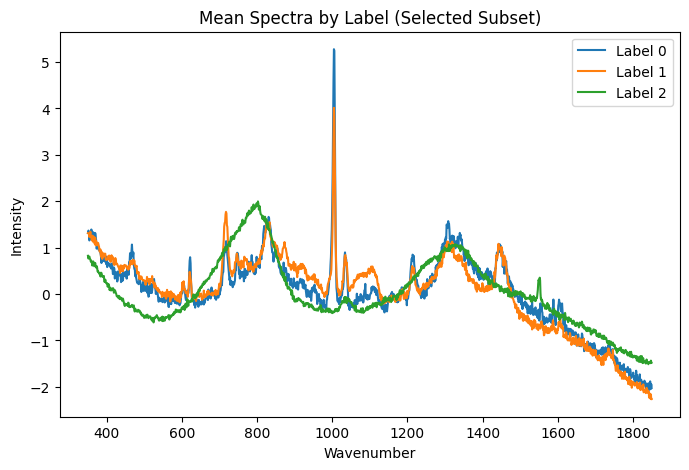

In [7]:
import matplotlib.pyplot as plt

unique_labels = np.unique(labels)

plt.figure(figsize=(8, 5))
for lbl in unique_labels:
    # Select all spectra for this label
    spectra_subset = spectra[labels == lbl]
    # Compute mean spectrum
    mean_spectrum = spectra_subset.mean(axis=0)
    plt.plot(common_wn_axis, mean_spectrum, label=f"Label {lbl}")

plt.xlabel("Wavenumber" if 'common_wn_axis' in locals() else "Wavenumber Index")
plt.ylabel("Intensity")
plt.title("Mean Spectra by Label (Selected Subset)")
plt.legend()
plt.show()

Visualise a single spectrum and return its predicted label, compare to its predicted label

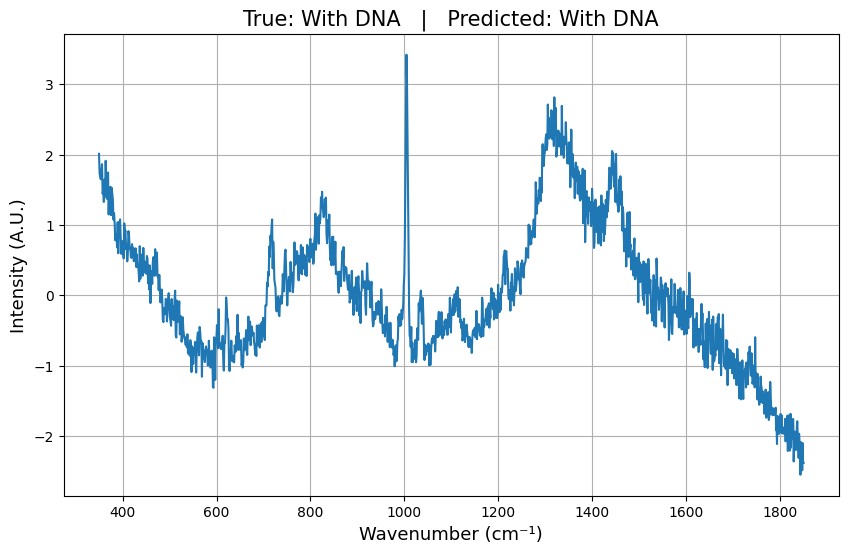

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

# ─── 1.  Adjust this index to choose any spectrum ───
idx = 6            # <-- change to 1, 2, … as you wish

spectrum      = spectra[idx]          # 1-D numpy array of length L
true_label_id = int(labels[idx])      # numeric ground-truth class

# Optional: map numeric IDs → readable class names
id2name = {0: "No DNA", 1: "With DNA", 2: "Steel Slide"}   # edit to match your dataset
true_label = id2name.get(true_label_id, f"class {true_label_id}")


model.eval()
# ─── 2.  Run inference on the chosen spectrum ───
x = torch.tensor(spectrum, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)  # -> [1, 1, L]
with torch.no_grad():
    logits = model(x)
pred_label_id = int(logits.argmax(dim=1).item())
pred_label    = id2name.get(pred_label_id, f"class {pred_label_id}")

# ─── 3.  Plot ───

plt.figure(figsize=(10, 6))
plt.plot(common_wn_axis, spectrum, label=f"Spectrum #{idx}")
plt.title(f"True: {true_label}   |   Predicted: {pred_label}", fontsize=15)
plt.xlabel("Wavenumber (cm⁻¹)", fontsize=13)
plt.ylabel("Intensity (A.U.)", fontsize=13)
plt.grid(True)
plt.show()


We will now use ReX to find explanations for why the model classifies these spectra the way it does.

In [9]:
# ReX needs to know the model input size

# 1️⃣  Spectrum length
L = spectra.shape[1]          # e.g. 1356 wavenumbers

# 2️⃣  Tell ReX the input shape it should expect. N is the batch size and can be left is for our purposes.
model_shape = ["N", 1, L]

In [10]:
from rex_xai.lib import ReX
print("ReX class:", ReX)

rex = ReX(model, model_shape, device, "spectral") # ReX works on various datatypes. Make sure its set to "spectral" for any spectral types.

ReX class: <class 'rex_xai.lib.ReX'>


First we'll explain a single spectrum

In [11]:
# We chose idx above, that's the spectrum we're explaining

sample = torch.tensor(spectra[idx], dtype=torch.float32) \
                  .unsqueeze(0).to(device)
rex.set_tabular_data(f"sample-{idx}", data=sample)
rex.set_target()
rex.calculate_responsibility()

100%|██████████| 20/20 [00:02<00:00,  7.92it/s]


In [12]:
# We can use rex.stats to get some diagnostics on ReX's performance. If, for instance everything was passing or everything was failing, we would know something is not right.
rex.stats

{'total_passing': 355,
 'total_failing': 919,
 'max_depth_reached': 3,
 'avg_box_size': 92.79375}

In [13]:
# We can extract the responsibility map like this
resp_map = np.asarray(rex.maps.get(0)).squeeze()


Text(0.5, 1.0, 'True: With DNA   |   Predicted: With DNA')

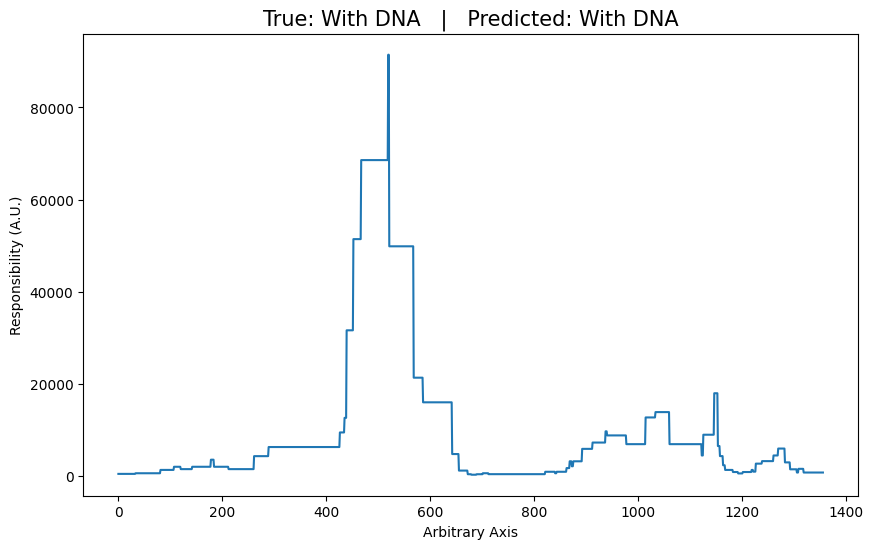

In [14]:
# We can extract the responsibility map like this
resp_map = np.asarray(rex.maps.get(0)).squeeze()


# Then we can plot the raw responsibility map like this
plt.figure(figsize=(10, 6))
plt.plot(resp_map)
plt.xlabel("Arbitrary Axis")
plt.ylabel("Responsibility (A.U.)")
plt.title(f"True: {true_label}   |   Predicted: {pred_label}", fontsize=15)

This is not very informative as we lack the wavenumber axis, which we'll now add. Note that, like when plotting a spectrum, we wavenumber axis may flip, depending on how the wavenumber axis was defined.

Text(0.5, 1.0, 'True: With DNA   |   Predicted: With DNA')

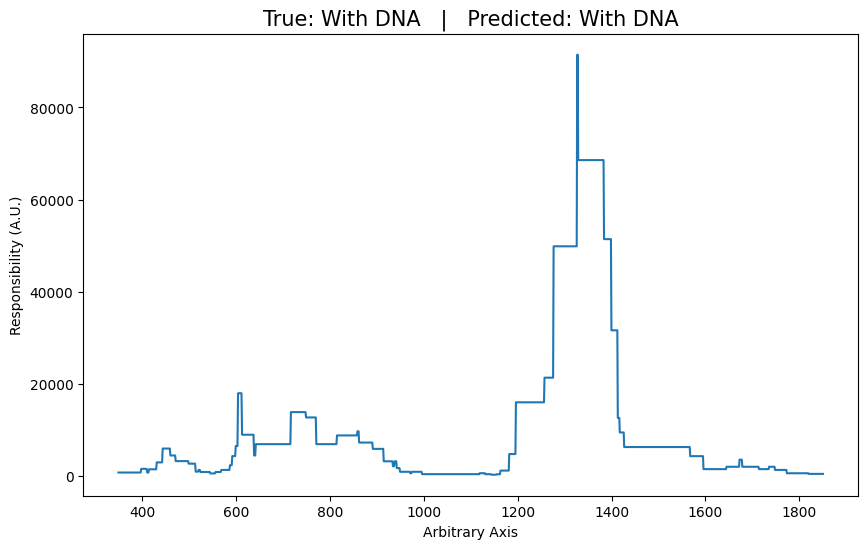

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(common_wn_axis, resp_map)
plt.xlabel("Arbitrary Axis")
plt.ylabel("Responsibility (A.U.)")
plt.title(f"True: {true_label}   |   Predicted: {pred_label}", fontsize=15)

We can make it even more informative by plotting this as a colourbar and adding the original spectrum on top. Not that the map values themselves are arbitrary, it just reflects how many times the model passed with that wavenumber present, but ReX has a dynamci number of attempts. It is the relative values which matter. For plotting we normalise them.

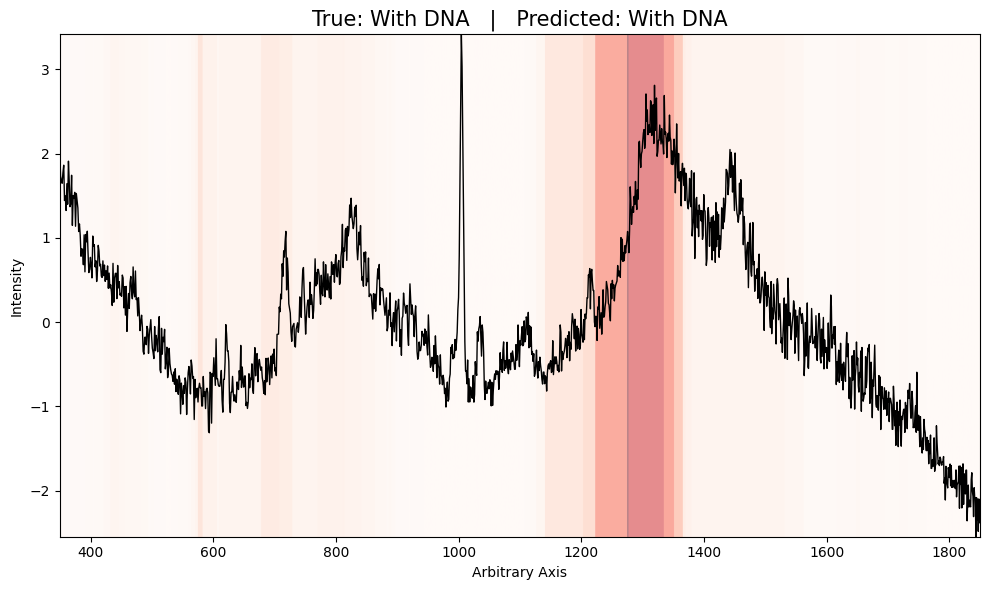

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# ── flip the responsibility map left-to-right ──
resp_map_flipped = resp_map[::-1]            # reverses element order. This is important when using the wavenumber axis, which will automatically flip the spectrum, but not the correspodning responsibility map

# normalise 0‒1 and reshape for imshow
norm  = resp_map_flipped / resp_map_flipped.max()
heat  = norm.reshape(1, -1)                  # (1, L)

fig, ax = plt.subplots(figsize=(10, 6))

# 1) spectrum in black
ax.plot(common_wn_axis, spectrum, color='black', linewidth=1)

# 2) red transparency overlay using the flipped map
ax.imshow(
    heat,
    cmap='Reds',
    aspect='auto',
    origin='lower',
    extent=[common_wn_axis.min(), common_wn_axis.max(),
            spectrum.min(),       spectrum.max()],
    alpha=0.5
)

ax.set_xlabel("Arbitrary Axis")
ax.set_ylabel("Intensity")
ax.set_title(f"True: {true_label}   |   Predicted: {pred_label}", fontsize=15)
plt.tight_layout()
plt.show()


We can now visually inspect the responsibilty map with its corresponding spectrum. We can repeat this process for any single spectrum in our dataset

Now we will extract a responsibilty map for every spectrum in our dataset and visualise mean spectra and difference spectra between classes

In [17]:
import numpy as np, torch

n = len(spectra)
assert n == len(labels), f"spectra={n}, labels={len(labels)}"

# storage
spectra_by_class   = {0: [], 1: [], 2: []}
resp_maps_by_class = {0: [], 1: [], 2: []}

for i in range(n):
    spec, lbl = spectra[i], int(labels[i])

    # run ReX on this sample
    sample = torch.tensor(spec, dtype=torch.float32).unsqueeze(0).to(device)
    rex.set_tabular_data(f"sample-{i}", data=sample)
    rex.set_target()
    rex.calculate_responsibility()

    # ── fetch the FIRST map returned ─────────────────────────────
    if not rex.maps.maps:                       # empty dict → hard fail
        raise RuntimeError(f"no map produced for sample {i}")

    resp_map = np.asarray(next(iter(rex.maps.maps.values()))).squeeze()

    # store
    spectra_by_class[lbl].append(spec)
    resp_maps_by_class[lbl].append(resp_map)

print({c: len(v) for c, v in resp_maps_by_class.items()})


100%|██████████| 20/20 [00:00<00:00, 30.65it/s]

{0: 5, 1: 5, 2: 5}


In [18]:
# flip in-place so each map now matches the orientation of common_wn_axis
for cls, maps in resp_maps_by_class.items():
    resp_maps_by_class[cls] = [m[::-1] for m in maps]


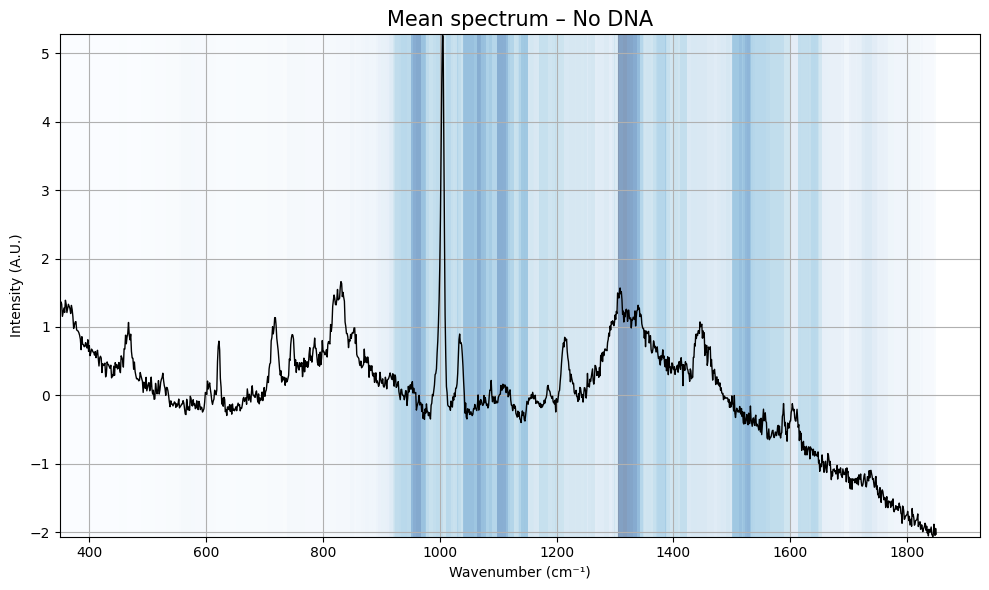

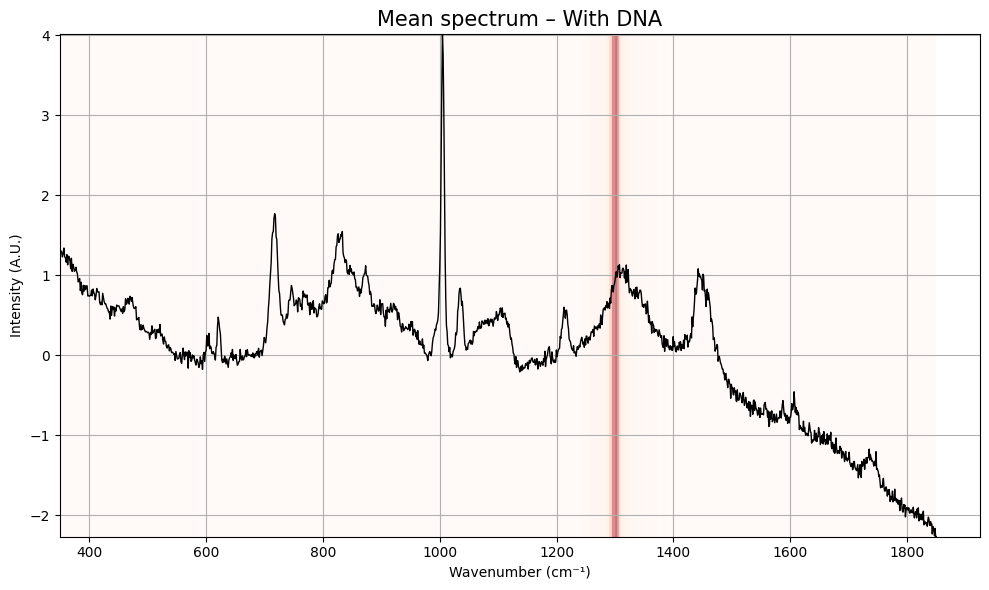

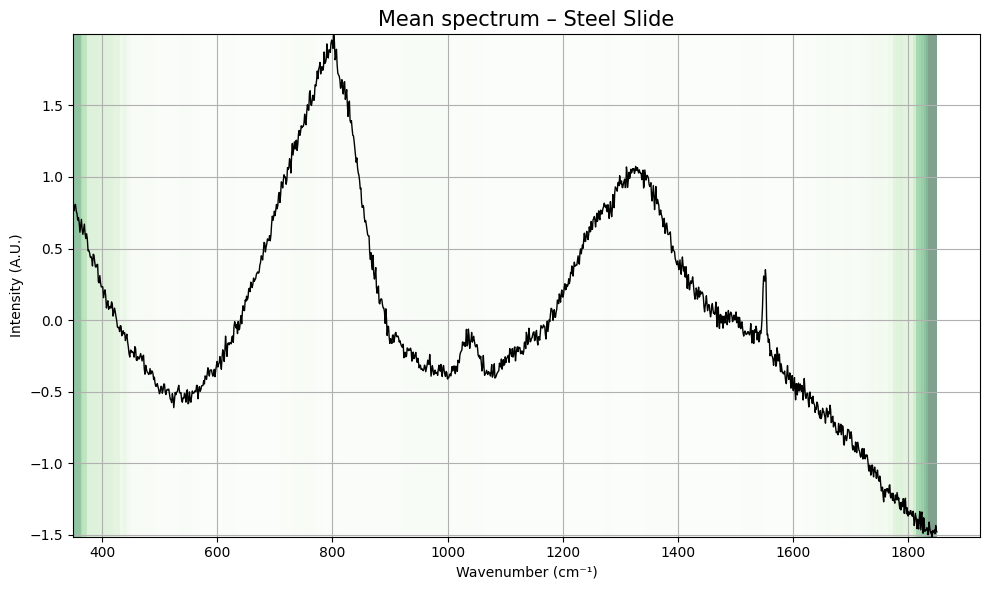

In [19]:
# ────────────────────────── MEAN SPECTRA + STRIPE OVERLAY (all classes) ──────────────────────────
id2name        = {0: "No DNA", 1: "With DNA", 2: "Steel Slide"}
cmap_per_class = {0: "Blues", 1: "Reds",  2: "Greens"}     # overlay colours

def mean_1d(arrays):
    return np.mean(np.stack(arrays, axis=0), axis=0)

for c in (0, 1, 2):
    class_name = id2name.get(c, f"class {c}")

    mspec = mean_1d(spectra_by_class[c])        # mean spectrum
    mmap  = mean_1d(resp_maps_by_class[c])      # mean responsibility map
    norm  = mmap / mmap.max()                   # 0–1

    # build irregular x-edges so pcolormesh honours the true Raman spacing
    wn = common_wn_axis
    edges = np.empty(len(wn) + 1)
    edges[1:-1] = (wn[:-1] + wn[1:]) / 2
    edges[0]    = wn[0]  + (wn[1]  - wn[0])  / 2
    edges[-1]   = wn[-1] + (wn[-1] - wn[-2]) / 2   # axis is descending

    y_edges = [mspec.min(), mspec.max()]       # full vertical span

    plt.figure(figsize=(10, 6))
    plt.plot(wn, mspec, color="black", linewidth=1)

    plt.pcolormesh(
        edges, y_edges, norm.reshape(1, -1),
        cmap=cmap_per_class[c], shading="auto", alpha=0.5
    )

    plt.title(f"Mean spectrum – {class_name}", fontsize=15)
    plt.xlabel("Wavenumber (cm⁻¹)")
    plt.ylabel("Intensity (A.U.)")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


We can see for class 0, no DNA, with model is typically using information 970-1100 cm^-1. For class 1, with DNA, the model focuses strongly on a peak at about 1300cm^-1. Let's find out exactly where this peak is:

In [20]:
# mean responsibility map for class 1
mean_resp_map_1 = mean_1d(resp_maps_by_class[1])      # 1-D array length L

# peak value and its index
idx_peak   = int(np.argmax(mean_resp_map_1))
peak_value = mean_resp_map_1[idx_peak]

# corresponding wavenumber
wn_peak = common_wn_axis[idx_peak]

print(f"Peak responsibility = {peak_value:.3g} at wavenumber {wn_peak} cm⁻¹ (index {idx_peak})")


Peak responsibility = 5.24e+19 at wavenumber 1302.3271484375 cm⁻¹ (index 543)


The peak responsibility is pretty much exactly at 1300 cm^-1. DNA associated peaks have been observed at ~1337.49 cm^-1 include: Amide III & CH2 wagging (glycine/proline), A,G ring breathing; Amide III and other protein groups;n(C-C)-lipids, fatty acids
At ~1246.39 cm^-1: Amide III (collagen); Amide III and other protein groups ; n(C-C)-lipids, fatty acids.

But out model has not exavctly learned these features in order to classify. So what's going on? This is a toy model, so it's likely leanred spurious correlations - this is useful information as the performance metrics were very high (but they will be if we have overfit our model).


The last class is interesting. The 'Steel Slide' class is actually a 'dustbin' class (i.e. anything not in class 0 or 1). This mostly involved noisy spectra from stainless steel and some other junk. Therefore we expect no features to be leanred. When this hapans, the underlying heuristics of ReX means we see repsonsibility collect at the edges (or in corners for images). When you see this, be suspicious - there is likely no actual information in that class.